# ĐỀ THI NHẬP MÔN AI

In [ ]:
#MSSV: 2374802010028
#HỌ VÀ TÊN: ĐẶNG ANH BẢO

# CÂU 1: TÌM BFS THEO ĐỒ THỊ BÊN DƯỚI BẰNG PYTHON

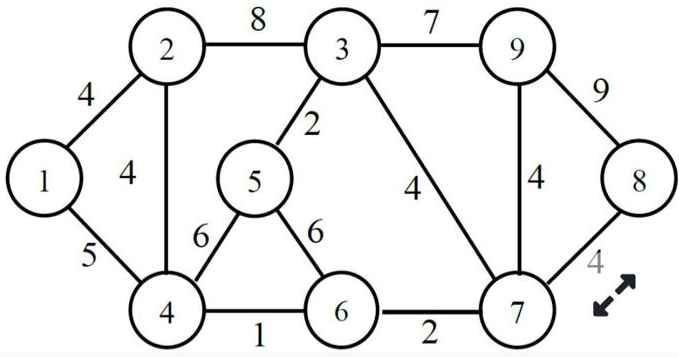

In [10]:
from collections import deque

def bfs_weighted(graph, start, goal):
    # Khởi tạo hàng đợi với nút bắt đầu, đường đi, và tổng trọng số
    queue = deque([(start, [start], 0)])
    # Khởi tạo tập hợp các nút đã thăm
    visited = set([start])
    
    # Lặp cho đến khi hàng đợi rỗng
    while queue:
        # Lấy nút, đường đi, và tổng trọng số từ đầu hàng đợi
        (node, path, total_weight) = queue.popleft()
        # Kiểm tra nếu nút hiện tại là đích
        if node == goal:
            return path, total_weight
        # Duyệt qua các nút kề và trọng số tương ứng
        for neighbor, weight in graph[node]:
            # Nếu nút kề chưa được thăm
            if neighbor not in visited:
                # Thêm nút kề vào tập đã thăm
                visited.add(neighbor)
                # Thêm nút kề, đường đi mới, và tổng trọng số cập nhật vào hàng đợi
                queue.append((neighbor, path + [neighbor], total_weight + weight))
    # Trả về None và 0 nếu không tìm thấy đường đi
    return None, 0

# Định nghĩa Đồ thị mẫu 5 (có trọng số)
graph5 = {
    '1': [('2', 4), ('4', 5)],
    '2': [('1', 4), ('4', 4), ('3', 8)],
    '3': [('2', 8), ('5', 2), ('7', 4), ('9', 7)],
    '4': [('1', 5), ('2', 4), ('5', 6), ('6', 1)],
    '5': [('4', 6), ('3', 2), ('6', 6)],
    '6': [('4', 1), ('5', 6), ('7', 2)],
    '7': [('6', 2), ('3', 4), ('9', 4), ('8', 4)],
    '8': [('7', 4), ('9', 9)],
    '9': [('3', 7), ('7', 4), ('8', 9)]
    
}

# Chạy BFS và in kết quả
path, weight = bfs_weighted(graph5, '1', '8')
print("Đường đi BFS trên Đồ thị mẫu 5:", path, "Tổng trọng số:", weight)

Đường đi BFS trên Đồ thị mẫu 5: ['1', '2', '3', '7', '8'] Tổng trọng số: 20


# CÂU 2: Tối ưu hóa hàm một biến

Tìm $x$ sao cho  
$$
f(x) = x^3 - 9x^2 + 24x - 10
$$  
đạt giá trị lớn nhất trong khoảng  
$$
x \in [0, 6].
$$

Thế hệ 1: x = 5.8398, f(x) = 224.1942
Thế hệ 2: x = 5.9525, f(x) = 224.1942
Thế hệ 3: x = 5.9979, f(x) = 236.6226
Thế hệ 4: x = 5.8605, f(x) = 241.7609
Thế hệ 5: x = 5.8605, f(x) = 226.4477
Thế hệ 6: x = 5.8353, f(x) = 226.4477
Thế hệ 7: x = 5.8353, f(x) = 223.7041
Thế hệ 8: x = 5.8353, f(x) = 223.7041
Thế hệ 9: x = 5.8353, f(x) = 223.7041
Thế hệ 10: x = 5.8353, f(x) = 223.7041
Thế hệ 11: x = 5.8353, f(x) = 223.7041
Thế hệ 12: x = 5.8350, f(x) = 223.7041
Thế hệ 13: x = 5.8350, f(x) = 223.6779
Thế hệ 14: x = 5.8350, f(x) = 223.6722
Thế hệ 15: x = 5.8350, f(x) = 223.6722
Thế hệ 16: x = 5.9761, f(x) = 223.6722
Thế hệ 17: x = 5.9761, f(x) = 239.2861
Thế hệ 18: x = 5.9761, f(x) = 239.2861
Thế hệ 19: x = 5.9408, f(x) = 239.2861
Thế hệ 20: x = 5.9408, f(x) = 235.3144
Thế hệ 21: x = 5.9364, f(x) = 235.3144
Thế hệ 22: x = 5.9342, f(x) = 234.8208
Thế hệ 23: x = 5.9342, f(x) = 234.5747
Thế hệ 24: x = 5.9336, f(x) = 234.5744
Thế hệ 25: x = 5.9336, f(x) = 234.5127
Thế hệ 26: x = 5.9334, f(x) = 234.

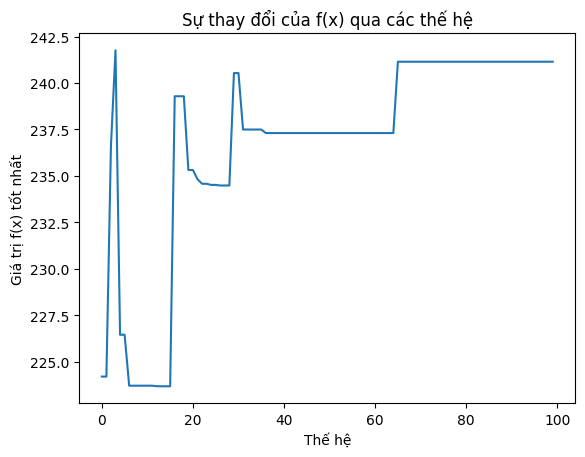


Kết quả cuối cùng: x = 5.9925, f(x) = 241.1451


In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Hàm mục tiêu
def fitness_function(x):
    return x**3 - ((9*x)*2) + 24*x - 10

# Khởi tạo quần thể
def initialize_population(pop_size, min_val, max_val):
    return [random.uniform(min_val, max_val) for _ in range(pop_size)]

# Lựa chọn (Tournament Selection)
def select_parents(population, fitness_values, tournament_size=3):
    selected = random.sample(range(len(population)), tournament_size)
    best_idx = max(selected, key=lambda i: fitness_values[i])
    return population[best_idx]

# Lai ghép
def crossover(parent1, parent2, crossover_rate=0.8):
    if random.random() < crossover_rate:
        return (parent1 + parent2) / 2
    return parent1

# Đột biến
def mutate(individual, mutation_rate=0.1, min_val=0, max_val=6):
    if random.random() < mutation_rate:
        return random.uniform(min_val, max_val)
    return individual

# Thuật toán di truyền
def genetic_algorithm_example1(pop_size=50, generations=100, min_val=0, max_val=6):
    population = initialize_population(pop_size, min_val, max_val)
    best_fitness_history = []
    
    for generation in range(generations):
        fitness_values = [fitness_function(x) for x in population]
        best_fitness = max(fitness_values)
        best_fitness_history.append(best_fitness)
        
        new_population = []
        for _ in range(pop_size):
            parent1 = select_parents(population, fitness_values)
            parent2 = select_parents(population, fitness_values)
            child = crossover(parent1, parent2)
            child = mutate(child)
            new_population.append(child)
        
        population = new_population
        best_individual = population[np.argmax([fitness_function(x) for x in population])]
        print(f'Thế hệ {generation + 1}: x = {best_individual:.4f}, f(x) = {best_fitness:.4f}')
    
    best_fitness = max([fitness_function(x) for x in population])
    best_individual = population[np.argmax([fitness_function(x) for x in population])]
    
    # Trực quan hóa
    plt.plot(range(generations), best_fitness_history)
    plt.xlabel('Thế hệ')
    plt.ylabel('Giá trị f(x) tốt nhất')
    plt.title('Sự thay đổi của f(x) qua các thế hệ')
    plt.show()
    
    return best_individual, best_fitness

# Chạy thuật toán
best_x, best_f = genetic_algorithm_example1()
print(f'\nKết quả cuối cùng: x = {best_x:.4f}, f(x) = {best_f:.4f}')


# CÂU 3: Triển khai thuật toán di truyền để tìm giá trị tối ưu của hàm số sau:

$$
f(x, y) = -(x^2 + y^2) + 10x + 8y + 50
$$

trong miền xác định:

$$
x, y \in [-5, 5].
$$

1. **Triển khai thuật toán di truyền bằng Python**:
   - **Biểu diễn lời giải**: Mỗi cá thể (chromosome) là một cặp số thực $(x, y)$.
   - **Hàm đánh giá (fitness function)**: Dựa trên giá trị của $f(x, y)$, với mục tiêu tìm giá trị lớn nhất.
   - **Toán tử di truyền**:
     - **Chọn lọc**: Sử dụng phương pháp tournament selection (chọn ngẫu nhiên $k=3$ cá thể, lấy cá thể tốt nhất).
     - **Lai ghép**: Triển khai lai ghép số học (arithmetic crossover), ví dụ: $x_{\text{new}} = \alpha x_1 + (1-\alpha) x_2$, với $\alpha$ ngẫu nhiên trong $[0, 1]$.
     - **Đột biến**: Áp dụng đột biến bằng cách thêm nhiễu Gaussian (mean=0, std=0.1) vào $x$ hoặc $y$, với xác suất đột biến nhỏ.
   - **Tham số**:
     - Kích thước quần thể: 50 cá thể.
     - Số thế hệ: 100 thế hệ.
     - Xác suất lai ghép: 0.8.
     - Xác suất đột biến: 0.05.
2. **Kết quả đầu ra**:
   - In ra giá trị tối ưu (gần đúng) của $f(x, y)$ và tọa độ $(x, y)$ tương ứng.
   - In ra giá trị hàm $f(x, y)$ tốt nhất qua từng thế hệ để theo dõi sự hội tụ.

Thế hệ 1: (x, y) = (4.0960, 3.0572), f(x, y) = 89.2941
Thế hệ 2: (x, y) = (4.0960, 3.0572), f(x, y) = 89.2941
Thế hệ 3: (x, y) = (4.1694, 3.0454), f(x, y) = 89.2941
Thế hệ 4: (x, y) = (4.1694, 3.0454), f(x, y) = 89.3988
Thế hệ 5: (x, y) = (4.1694, 3.0454), f(x, y) = 89.3988
Thế hệ 6: (x, y) = (4.2061, 3.0541), f(x, y) = 89.3988
Thế hệ 7: (x, y) = (4.2366, 3.0377), f(x, y) = 89.4750
Thế hệ 8: (x, y) = (4.2366, 3.0377), f(x, y) = 89.4912
Thế hệ 9: (x, y) = (4.2899, 3.0456), f(x, y) = 89.4912
Thế hệ 10: (x, y) = (4.2269, 3.1251), f(x, y) = 89.5849
Thế hệ 11: (x, y) = (4.1975, 3.2917), f(x, y) = 89.6369
Thế hệ 12: (x, y) = (4.1970, 3.2835), f(x, y) = 89.8542
Thế hệ 13: (x, y) = (4.4635, 3.1518), f(x, y) = 89.8418
Thế hệ 14: (x, y) = (4.4495, 3.2203), f(x, y) = 89.9927
Thế hệ 15: (x, y) = (4.4428, 3.3433), f(x, y) = 90.0889
Thế hệ 16: (x, y) = (4.4289, 3.4357), f(x, y) = 90.2583
Thế hệ 17: (x, y) = (4.4281, 3.4288), f(x, y) = 90.3555
Thế hệ 18: (x, y) = (4.4756, 3.5323), f(x, y) = 90.3467
T

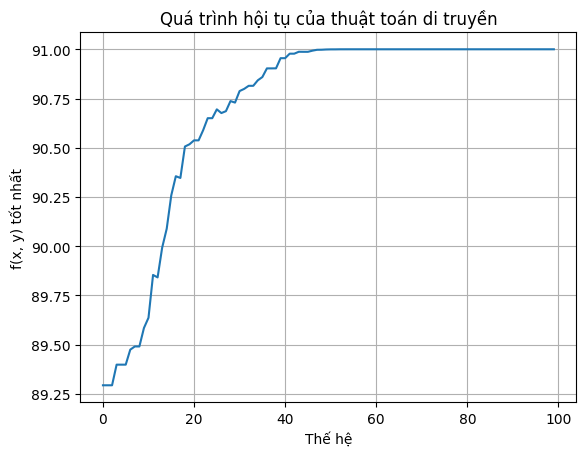


Kết quả cuối cùng: (x, y) = (5.0000, 4.0002), f(x, y) = 91.0000


In [20]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Hàm mục tiêu (fitness function)
def fitness_function_xy(x, y):
    return -(x**2 + y**2) + 10*x + 8*y + 50

# Khởi tạo quần thể: mỗi cá thể là một tuple (x, y)
def initialize_population(pop_size, min_val, max_val):
    return [(random.uniform(min_val, max_val), random.uniform(min_val, max_val)) for _ in range(pop_size)]

# Tournament Selection
def select_parents(population, fitness_values, tournament_size=3):
    selected = random.sample(range(len(population)), tournament_size)
    best_idx = max(selected, key=lambda i: fitness_values[i])
    return population[best_idx]

# Lai ghép số học (Arithmetic crossover)
def crossover(parent1, parent2, crossover_rate=0.8):
    if random.random() < crossover_rate:
        alpha = random.random()
        child_x = alpha * parent1[0] + (1 - alpha) * parent2[0]
        child_y = alpha * parent1[1] + (1 - alpha) * parent2[1]
        return (child_x, child_y)
    return parent1

# Đột biến Gaussian
def mutate(individual, mutation_rate=0.05, min_val=-5, max_val=5):
    x, y = individual
    if random.random() < mutation_rate:
        x += random.gauss(0, 0.1)
    if random.random() < mutation_rate:
        y += random.gauss(0, 0.1)
    # Giới hạn giá trị sau đột biến
    x = min(max(x, min_val), max_val)
    y = min(max(y, min_val), max_val)
    return (x, y)

# Thuật toán di truyền
def genetic_algorithm_xy(pop_size=50, generations=100, min_val=-5, max_val=5):
    population = initialize_population(pop_size, min_val, max_val)
    best_fitness_history = []
    
    for generation in range(generations):
        fitness_values = [fitness_function_xy(x, y) for x, y in population]
        best_fitness = max(fitness_values)
        best_fitness_history.append(best_fitness)

        new_population = []
        for _ in range(pop_size):
            parent1 = select_parents(population, fitness_values)
            parent2 = select_parents(population, fitness_values)
            child = crossover(parent1, parent2)
            child = mutate(child, min_val=min_val, max_val=max_val)
            new_population.append(child)

        population = new_population
        best_idx = np.argmax([fitness_function_xy(x, y) for x, y in population])
        best_individual = population[best_idx]
        print(f"Thế hệ {generation + 1}: (x, y) = ({best_individual[0]:.4f}, {best_individual[1]:.4f}), f(x, y) = {best_fitness:.4f}")

    # Kết quả cuối cùng
    fitness_values = [fitness_function_xy(x, y) for x, y in population]
    best_idx = np.argmax(fitness_values)
    best_individual = population[best_idx]
    best_fitness = fitness_values[best_idx]

    # Vẽ biểu đồ hội tụ
    plt.plot(range(generations), best_fitness_history)
    plt.xlabel('Thế hệ')
    plt.ylabel('f(x, y) tốt nhất')
    plt.title('Quá trình hội tụ của thuật toán di truyền')
    plt.grid(True)

    plt.show()

    return best_individual, best_fitness

# Chạy thuật toán
best_xy, best_f = genetic_algorithm_xy()
print(f"\nKết quả cuối cùng: (x, y) = ({best_xy[0]:.4f}, {best_xy[1]:.4f}), f(x, y) = {best_f:.4f}")

# CÂU 4: NAIVE BAYES 

**Tập dữ liệu**: Dữ liệu về quyết định mua máy tính của 14 khách hàng, với các đặc trưng: Age (youth, middle_aged, senior), Income (low, medium, high), Student (yes, no), Credit_rating (fair, excellent), và nhãn Buys_computer (yes, no).

| ID | Age         | Income | Student | Credit_rating | Buys_computer |
|----|-------------|--------|---------|---------------|---------------|
| 1  | youth       | high   | no      | fair          | no            |
| 2  | youth       | high   | no      | excellent     | no            |
| 3  | middle_aged | high   | no      | fair          | yes           |
| 4  | senior      | medium | no      | fair          | yes           |
| 5  | senior      | low    | yes     | fair          | yes           |
| 6  | senior      | low    | yes     | excellent     | no            |
| 7  | middle_aged | low    | yes     | excellent     | yes           |
| 8  | youth       | medium | no      | fair          | no            |
| 9  | youth       | low    | yes     | fair          | yes           |
| 10 | senior      | medium | yes     | fair          | yes           |
| 11 | youth       | medium | yes     | excellent     | yes           |
| 12 | middle_aged | medium | no      | excellent     | yes           |
| 13 | middle_aged | high   | yes     | fair          | yes           |
| 14 | senior      | medium | no      | excellent     | no            |

1. **Triển khai thuật toán Naive Bayes từ đầu**:
   - **Biểu diễn dữ liệu**: Lưu trữ tập dữ liệu trong chương trình (dùng danh sách, dictionary, hoặc pandas DataFrame).
   - **Tính xác suất**:
     - Tính xác suất trước (prior probabilities) cho lớp Buys_computer (Yes/No).
     - Tính xác suất có điều kiện (likelihood) cho từng giá trị của các đặc trưng (Age, Income, Student, Credit_rating) đối với từng lớp.
   - **Dự đoán**: Viết hàm dự đoán nhãn Buys_computer cho một mẫu dữ liệu mới dựa trên thuật toán Naive Bayes.
   - **Xử lý dữ liệu categorical**: Chuyển đổi các giá trị categorical thành dạng số hoặc xử lý trực tiếp trong tính toán xác suất.
2. **Dự đoán mẫu mới**:
   - Sử dụng chương trình để dự đoán nhãn Buys_computer cho mẫu: Age = youth, Income = medium, Student = yes, Credit_rating = fair.
   - In ra xác suất dự đoán cho cả hai lớp (Yes và No) và nhãn cuối cùng.

In [ ]:
#CODE HERE
